In [3]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


In [4]:
df= pd.read_csv('/content/netflix_titles_2021.csv')

In [5]:
# İlk 5 satır yazdırma
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
#rastgele beş satır
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4502,s4503,Movie,Mr. Chandramouli,Thiru,"Karthik, Gautam Karthik, Regina Cassandra, Var...",India,"October 18, 2018",2018,TV-MA,131 min,"Dramas, International Movies, Thrillers",When the lives of a carefree boxer and his cab...
7311,s7312,Movie,Little Dragon Maiden,Hua Shan,"Leslie Cheung, Jing-Jing Yung, Chen Kuan-tai, ...",Hong Kong,"August 1, 2018",1983,TV-14,92 min,"Action & Adventure, International Movies, Roma...","Seeking to improve his combat skills, a young ..."
4890,s4891,Movie,John Mulaney: Kid Gorgeous at Radio City,Alex Timbers,John Mulaney,United States,"May 1, 2018",2018,TV-MA,65 min,Stand-Up Comedy,John Mulaney relays stories from his childhood...
659,s660,TV Show,Bangkok Love Stories: Innocence,NaN,"Nida Patcharaveerapong, Nicole Theriault, Natt...",Thailand,"June 19, 2021",2018,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",From a teenage parkour enthusiast to a bawdy r...
261,s262,Movie,The Secret Diary of an Exchange Student,Bruno Garotti,"Larissa Manoela, Thati Lopes, Bruno Montaleone...",NaN,"August 18, 2021",2021,TV-14,97 min,"Comedies, International Movies, Romantic Movies","Looking to shake things up, two best friends e..."


In [7]:
# Veri tiplerini bulalım
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
       sütun veri tipi  null değeri  null oranı(%)  unıque
     show_id    object            0           0.00    8807
        type    object            0           0.00       2
       title    object            0           0.00    8807
    director    object         2634          29.91    4528
        cast    object          825           9.37    7692
     country    object          831           9.44     748
  date_added    object           10           0.11    1767
release_year     int64            0           0.00      74
      rating    object            4           0.05      17
    duration    object            3           0.03     220
   listed_in    object            0           0.00     514
 description    object            0           0.00    8775


In [8]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.00,2014.18,8.82,1925.00,2013.00,2017.00,2019.00,2021.00


In [9]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
show_id,8807,8807,s8807,1
type,8807,2,Movie,6131
title,8807,8807,Zubaan,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


In [10]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

In [11]:
### Eksik Veri Analizi

empty_values = df.isnull().sum()
empty_rate = (empty_values / len(df) * 100).round(2)
empty_df = pd.concat([empty_values, empty_rate], axis=1)
empty_df.columns = ["empty_count", "empty_rate"]

# Sıralanmış hali tekrar empty_df değişkenine atanmalı
empty_df = empty_df.sort_values("empty_rate", ascending=False)

empty_df

,empty_count,empty_rate
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


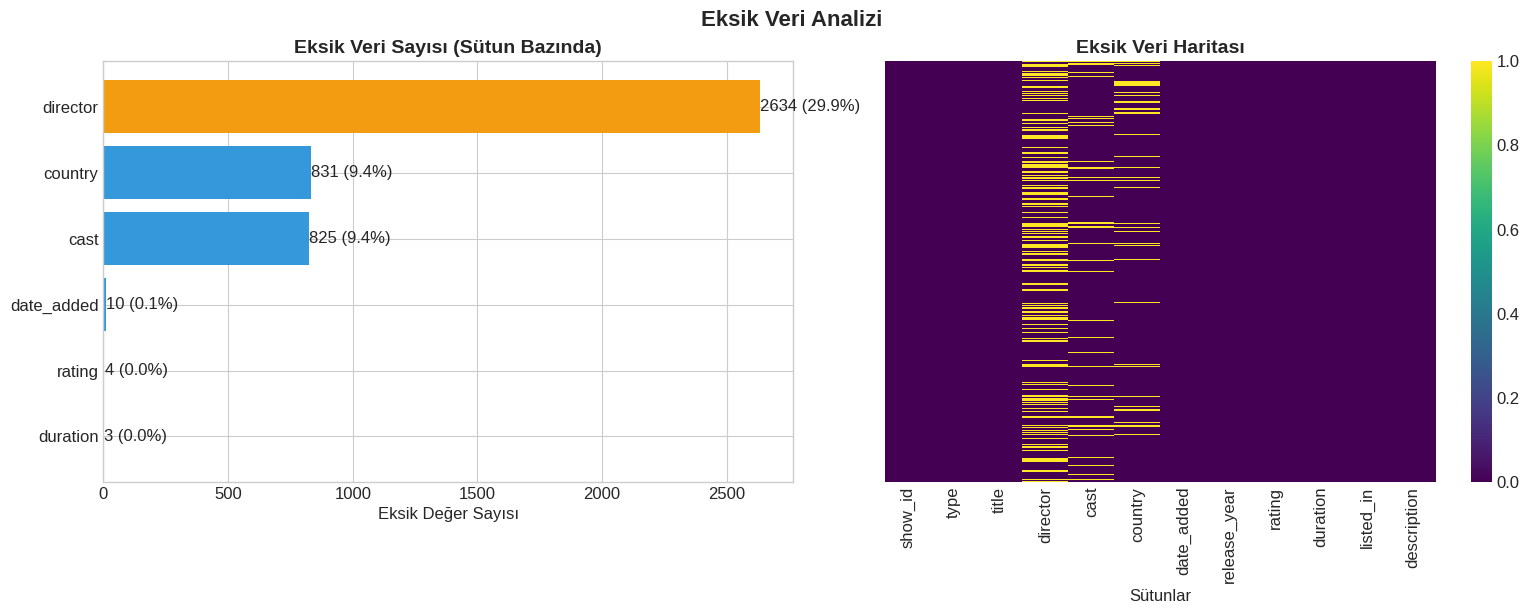

In [12]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [13]:
# aykırı değer fazla olduğunda sayısal verilerde medyan kullanılır ancak
# bu veri setinde eksik sayısal veri yok. Kategorik olan 'director' için sabit değer atıyoruz.
df_temiz = df.copy()

df_temiz['director'].fillna('Belirsiz', inplace=True)
print(df_temiz.isnull().sum())

show_id           0
type              0
title             0
director          0
cast            825
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64


In [14]:
# Mod ise en çok görülen değerle doldurur
# 'embarked' yerine Netflix veri setindeki 'country' sütununu kullanıyoruz
country_mod = df_temiz['country'].mode()[0]
df_temiz['country'].fillna(country_mod, inplace=True)
print(df_temiz.isnull().sum())

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64


In [15]:
# 'deck' sütunu yerine eksik verisi olan 'cast' sütununu ele alıyoruz
# Metin verisi olduğu için ilk harf almak yerine doğrudan eksikleri dolduruyoruz
df_temiz['cast'].fillna('Belirsiz', inplace=True)
print(df_temiz['cast'].value_counts().head())

cast
Belirsiz                                                                                   825
David Attenborough                                                                          19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil     14
Samuel West                                                                                 10
Jeff Dunham                                                                                  7
Name: count, dtype: int64


In [16]:
### Tek değişkenli analiz

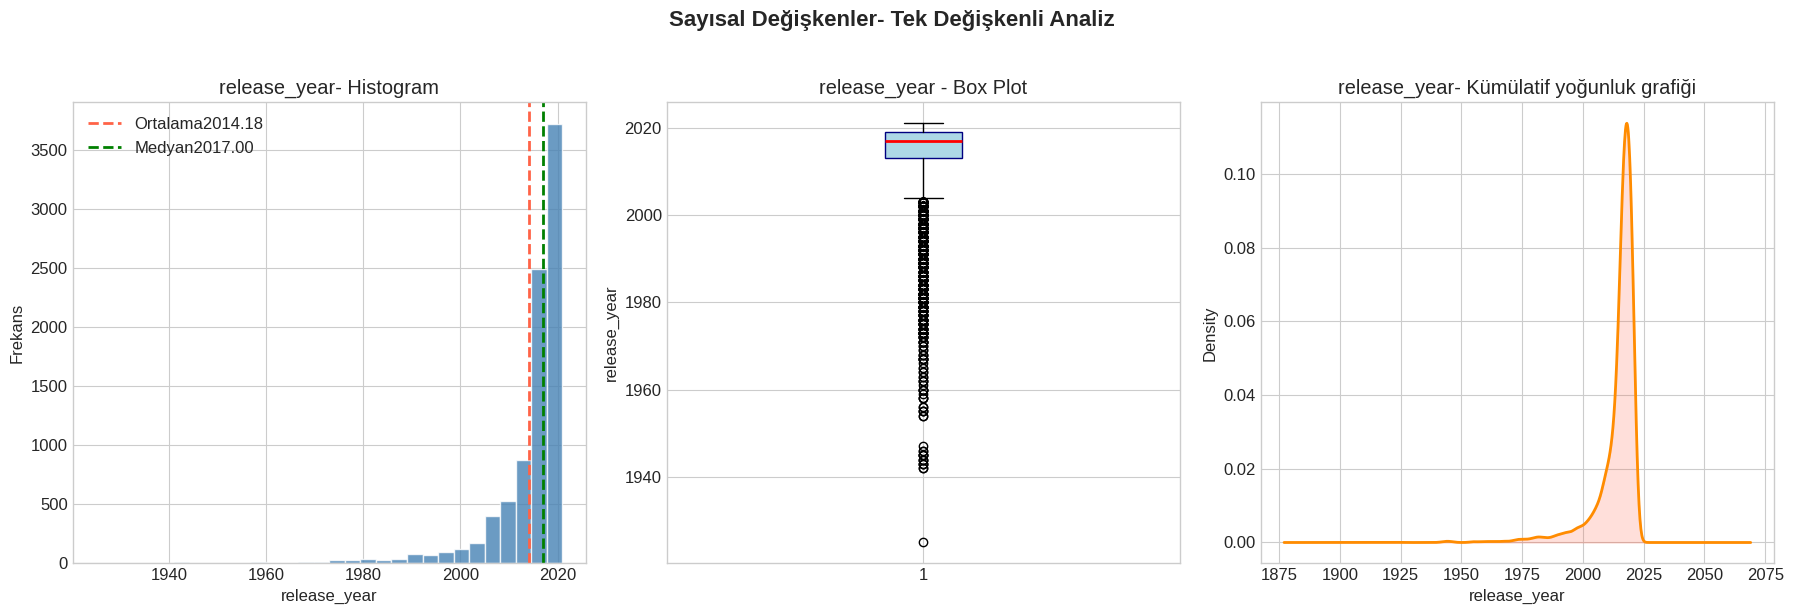

In [ ]:
# sayısal değişkenler
sayisal_kolonlar =['release_year']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

# Tek bir değişken olduğu için matplotlib eksen indekslemesinin [i, j] formatında çalışabilmesi adına
import numpy as np
if len(sayisal_kolonlar) == 1:
    axes = np.array([axes])

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_temiz[kolon].dropna()

    axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
    axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
    axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
    axes[i,0].set_title(f'{kolon}- Histogram')
    axes[i,0].legend()
    axes[i,0].set_xlabel(kolon)
    axes[i,0].set_ylabel('Frekans')

    # Box plot
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} - Box Plot')
    axes[i, 1].set_ylabel(kolon)

    veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
    axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                           axes[i,2].lines[0].get_ydata(),
                           color='tomato',alpha=0.2)
    axes[i,2].set_title(f'{kolon}- Kümülatif yoğunluk grafiği')
    axes[i,2].set_xlabel(kolon)

plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_temiz[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * RELEASE_YEAR
Ortalama: 2014.18
Medyan: 2017.00
Standart Sapma: 8.82
Minimum: 1925.00
Maksimum: 2021.00
Varyans: 77.78
Skewness(Çarpıklık): -3.45
Kurtosis(Basıklık): 16.23
IQR: 6.00


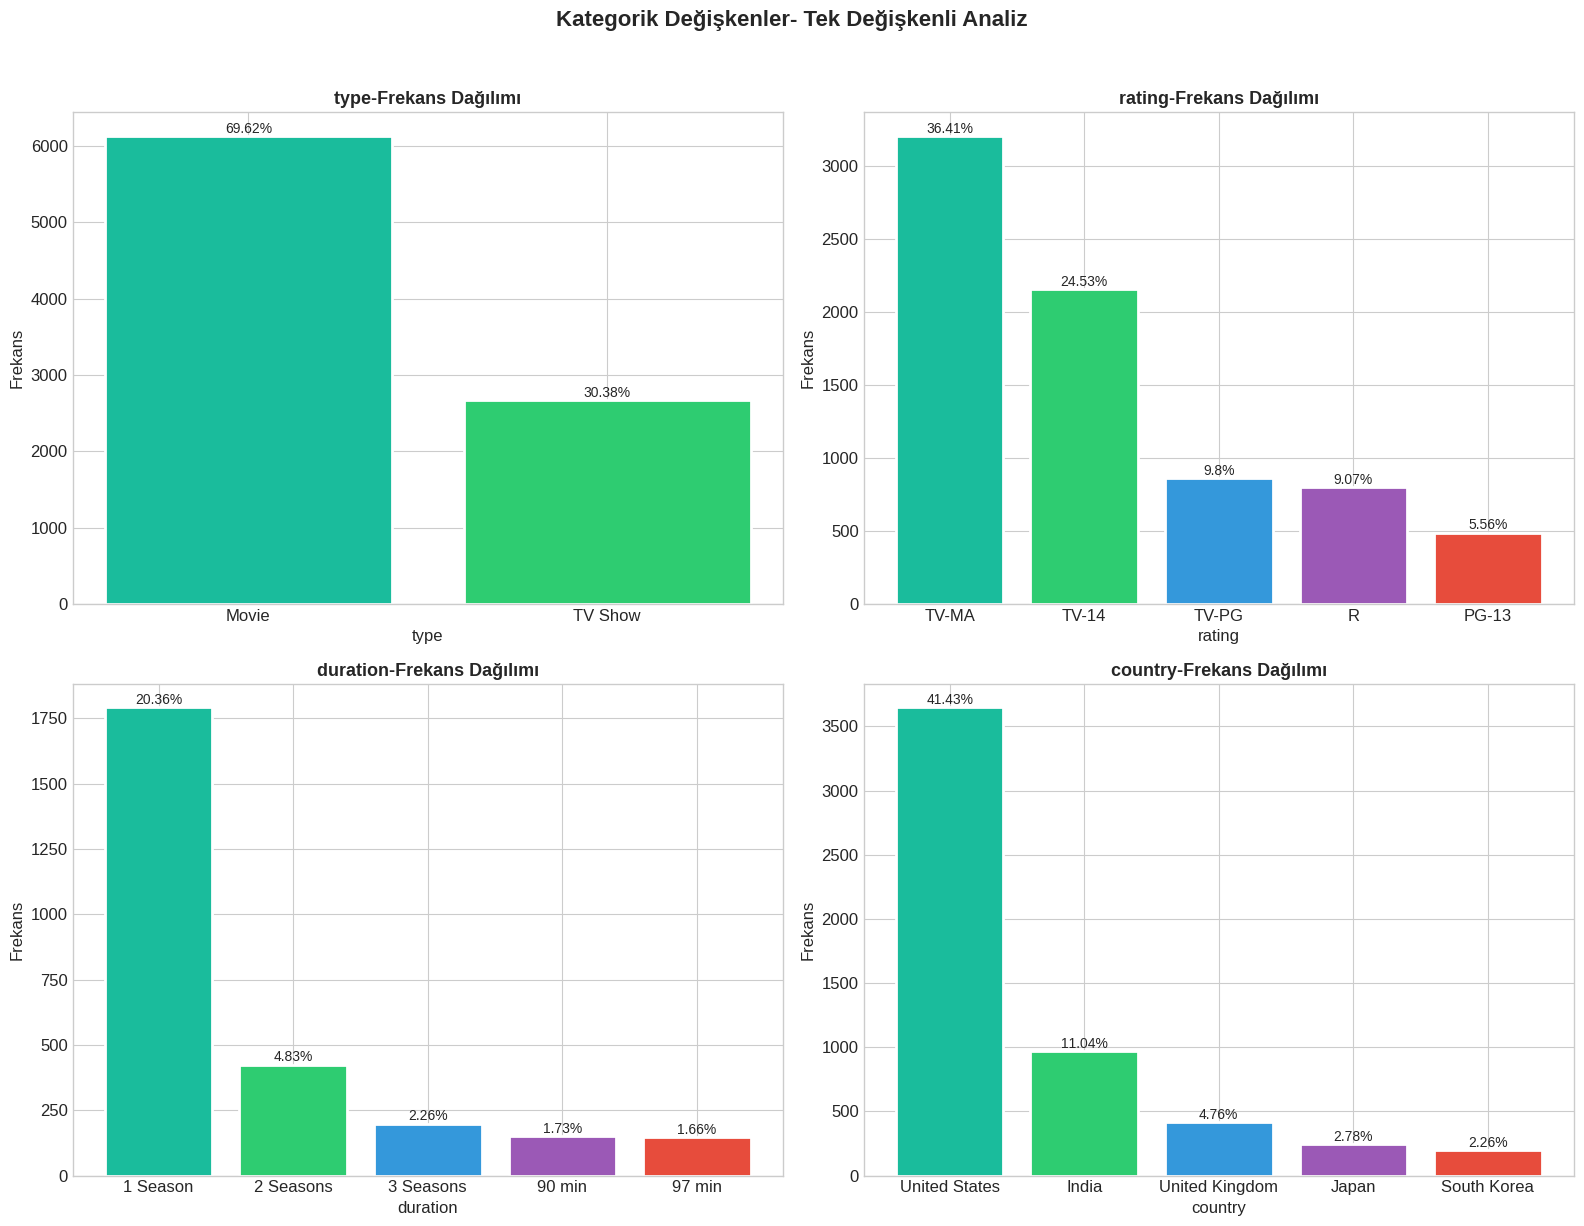

In [ ]:
### Kategorik kolon

kategorik_kolonlar = ['type', 'rating', 'duration', 'country']
fig,axes = plt.subplots(2,2,figsize=(16,12))
axes=axes.flatten()

renkler = ['#1ABC9C', '#2ECC71', '#3498DB', '#9B59B6', '#E74C3C', '#F1C40F']
for i,kolon in enumerate(kategorik_kolonlar):
    # Çok fazla benzersiz değer içeren country ve duration kolonları için en popüler ilk 5 değeri alıyoruz
    if kolon in ['country', 'duration', 'rating']:
        degerler=df_temiz[kolon].value_counts().head(5)
    else:
        degerler=df_temiz[kolon].value_counts()

    yuzde = (degerler/len(df_temiz)*100).round(2)

    bars = axes[i].bar(degerler.index.astype(str),degerler.values,
                       color = renkler[:len(degerler)],edgecolor='white',linewidth=2)

    axes[i].set_title(f'{kolon}-Frekans Dağılımı',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')

    for bar ,pct in zip(bars,yuzde.values):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+1,
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=10)
plt.suptitle('Kategorik Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
### Çift değişkenli Analiz